In [2]:
!pip install plotly

In [3]:
!pip install cufflinks

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for cufflinks: filename=cufflinks-0.17.3-py3-none-any.whl size=68721 sha256=2b27609984702f08a98422bb5c2fa3b7b3bc6b04b556b6964909a79effdc16e8
  Stored in directory: c:\users\lenovo\appdata\local\pip\cache\wheels\c0\d9\70\372130dacf508192607c1a7359c7bf0656b1a3b79f6cf66f7a
Successfully built cufflinks


In [5]:
import pandas as pd
import cufflinks as cf
from IPython.display import display, HTML
cf.set_config_file(sharing='public', theme='ggplot', offline=True)

In [7]:
# reading csv
df_population_raw = pd.read_csv('population_total.csv')
#dropping null values
df_population_raw.dropna(inplace=True)
#making a pivot table
df_pivot = df_population_raw.pivot(index='year', columns='country', 
                                   values='population')
#selecting some countries
df_pivot = df_pivot[['United States','India',
                     'China','Indonesia','Brazil']]
# showing pivot table
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


# 1 Lineplot

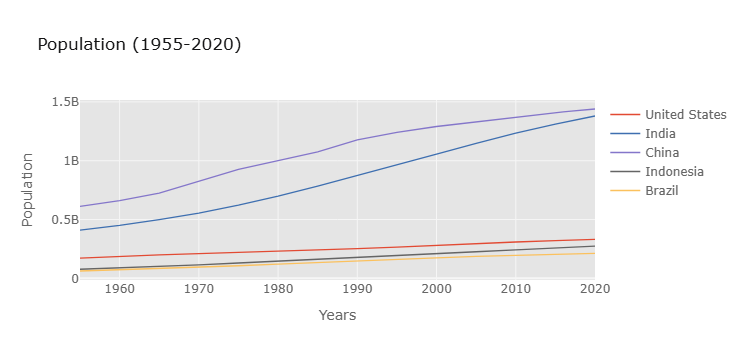

In [12]:
df_pivot.iplot(kind='line',
              xTitle='Years',
              yTitle='Population',
              title='Population (1955-2020)')

# 2 Barplot

In [13]:
# selecting only one year (2020)
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])]
# transport dataframe from rows to columns or vice versa
df_pivot_2020 = df_pivot_2020.T

In [14]:
df_pivot_2020

year,2020.0
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


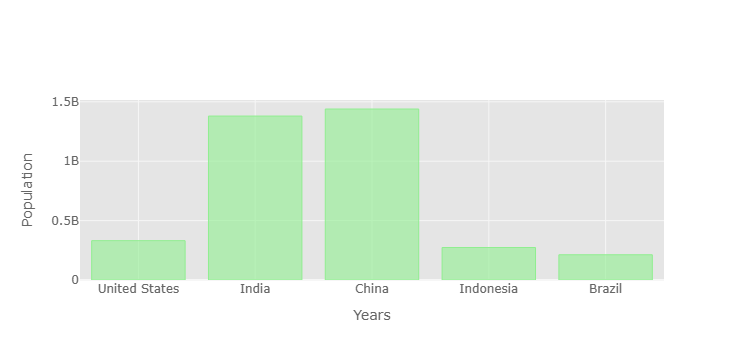

In [15]:
df_pivot_2020.iplot(kind='bar', color='lightgreen', 
                    xTitle='Years', yTitle='Population')

## 2.1 Barplot grouped by 'n' variables

In [16]:
# selecting a few year
df_pivot_sample = df_pivot[df_pivot.index.isin([1980,1990,2000,2010,2020])]

In [17]:
df_pivot_sample

country,United States,India,China,Indonesia,Brazil
year,,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,211513823.0,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,241834215.0,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


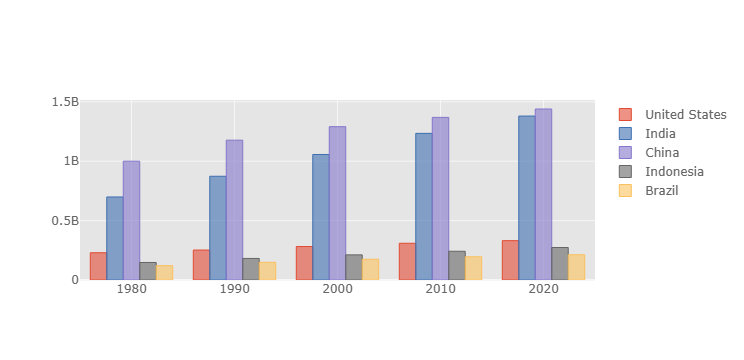

In [18]:
df_pivot_sample.iplot(kind='bar')

# 3 Piechart

In [20]:
# changing column name
df_pivot_2020.rename(columns={2020:'2020'}, inplace=True)

In [25]:
df_pivot_2020=df_pivot_2020.reset_index()

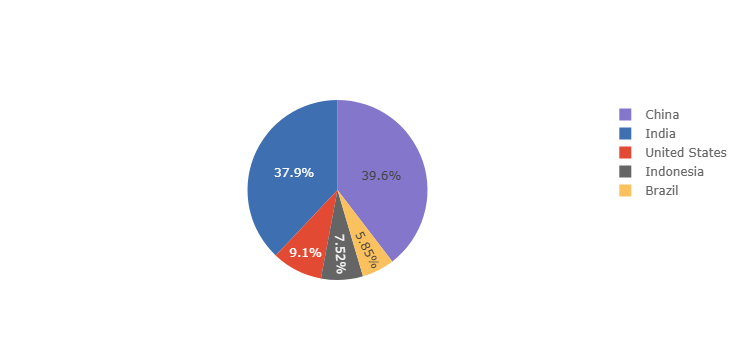

In [26]:
df_pivot_2020.iplot(kind='pie', values='2020', labels='country')

# 4 Boxplot

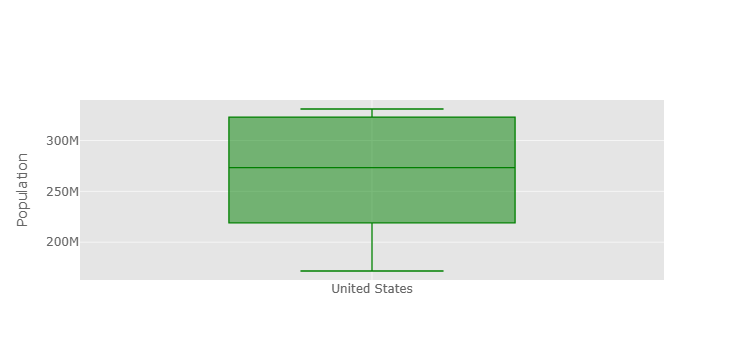

In [28]:
df_pivot['United States'].iplot(kind='box', color='green', yTitle='Population')

## 4.1 Multiple Boxplots

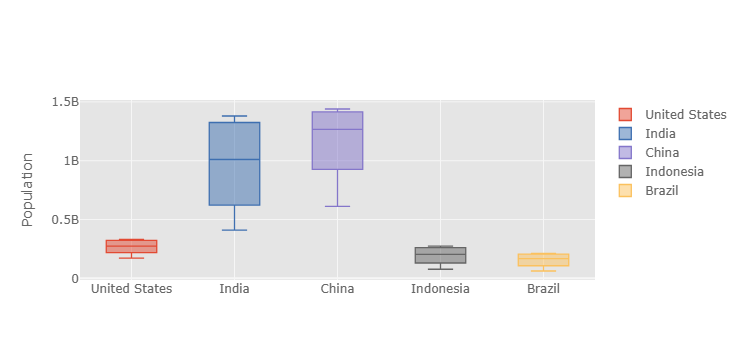

In [29]:
df_pivot.iplot(kind='box', yTitle='Population')

# 5 Histogram

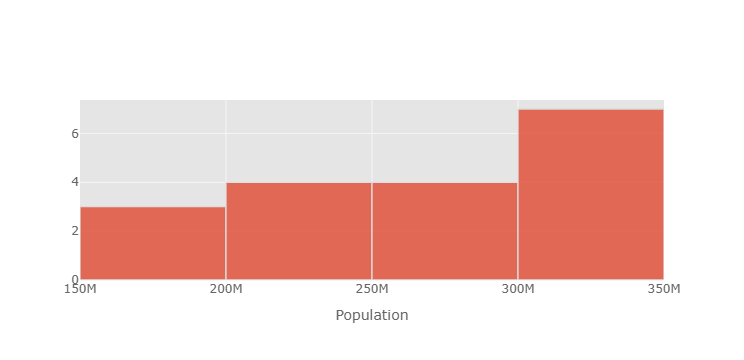

In [33]:
df_pivot['United States'].iplot(kind='hist', xTitle='Population')

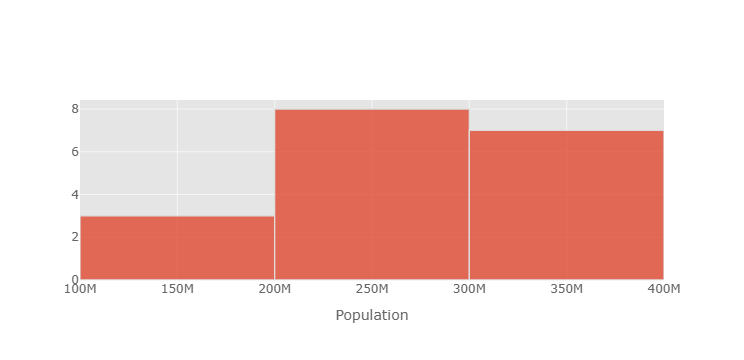

In [32]:
df_pivot['United States'].iplot(kind='hist', xTitle='Population', bins=3)

## 5.1 Multiple Histograms

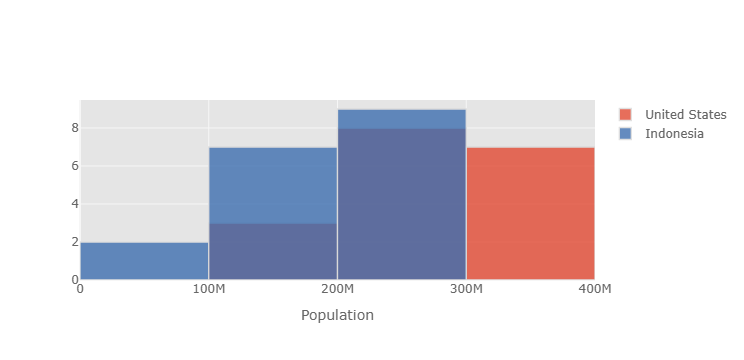

In [34]:
df_pivot[['United States','Indonesia']].iplot(kind='hist', xTitle='Population', bins=3)

# 6 ScatterPlot

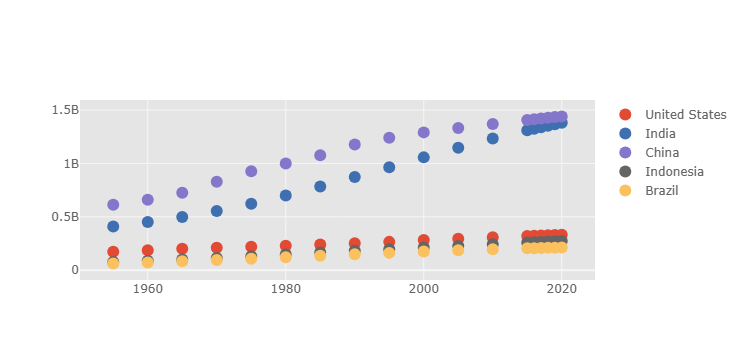

In [35]:
df_pivot.iplot(kind='scatter', mode='markers')